In [1]:
import pathlib
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
import xarray as xr

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

2024-07-23 11:13:47.639112: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-23 11:13:48.118584: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [61]:
tfrecord_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run1')
analysis_dir = pathlib.Path('/gpfs/work2/0/prjs1027/guus/analysis')
analysis_dir.mkdir(exist_ok=True, parents=True)
output_variables = ["hs", "theta0_x", "theta0_y", "tmm10", "tps", "hswe"]
input_variables = ["xwnd", "ywnd", "ssh", "xcur", "ycur"]
boundary_variables = ["hs_bnd", "hswe_bnd", "tmm10_bnd"]
variable_fields = input_variables + output_variables + boundary_variables

min_max_values = xr.open_dataset(tfrecord_dir / "min-max-values/min-max-values.nc")

for bnd_var in boundary_variables:
    min_max_values[bnd_var] = min_max_values[bnd_var.split("_")[0]]

min_max_values["theta0_x"] = xr.DataArray(np.array([0., 1.]), dims='index')
min_max_values["theta0_y"] = xr.DataArray(np.array([0., 1.]), dims='index')

In [3]:
learning_rate = 1e-4
n_epochs = 100
batch_size = 4
steps_per_execution = 1

model_version = "swan_ens_nn_v0001"

src_dir = pathlib.Path().resolve()
model_dir = src_dir / f"trained_models/{model_version}"
model_dir.mkdir(exist_ok=True, parents=True)

raster_shape = (481, 421, 2)
widths = [16, 32, 64, 128, 256, 256]
block_depth = 3

In [4]:
def get_files(data_path):
    files = tf.io.gfile.glob(data_path + "/" + "*.tfrecords")
    return files


def get_dataset(files):
    """return a tfrecord dataset with all tfrecord files"""
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(tf_parse)
    return dataset


def tf_parse(eg, variable_fields=variable_fields):
    """parse an example (or batch of examples, not quite sure...)"""

    # here we re-specify our format
    # you can also infer the format from the data using tf.train.Example.FromString
    # but that did not work
    parse_dict =         {
            "height": tf.io.FixedLenFeature([], tf.int64),
            "width": tf.io.FixedLenFeature([], tf.int64),
            "depth": tf.io.FixedLenFeature([], tf.int64),
        }

    vars = variable_fields
    for var in vars:
        parse_dict[var] = tf.io.FixedLenFeature([], tf.string)

    example = tf.io.parse_example(
        eg[tf.newaxis],
        parse_dict,
    )

    variables = {}
    for var in variable_fields:
        variables[var] = tf.io.parse_tensor(example[var][0], out_type="float32")
        # variables[var] = (variables[var] - min_max_values[var].values[0]) / (min_max_values[var].values[1] - min_max_values[var].values[0])
        variables[var] = tf.where(tf.math.is_nan(variables[var]), tf.zeros_like(variables[var]) - 1, variables[var])
        if var in output_variables:
            variables[var] = variables[var][..., -1]
            variables[var] = tf.reshape(variables[var], (481, 421, 1))
        else:
            variables[var] = (variables[var] - min_max_values[var].values[0]) / (min_max_values[var].values[1] - min_max_values[var].values[0])


    variables["hs_bnd"] = tf.reshape(variables["hs_bnd"], (22, 1))
    variables["tmm10_bnd"] = tf.reshape(variables["tmm10_bnd"], (22, 1))
    variables["hswe_bnd"] = tf.reshape(variables["hswe_bnd"], (22, 1))
    boundary_inputs = tf.concat([variables["hs_bnd"], variables["tmm10_bnd"], variables["hswe_bnd"]], axis=-1)

    inputs = (variables["xwnd"], variables["ywnd"], variables["ssh"], variables["xcur"], variables["ycur"], boundary_inputs)
    outputs = (variables["hs"], variables["theta0_x"], variables["theta0_y"], variables["tmm10"], variables["tps"], variables["hswe"])

    return inputs, outputs

In [5]:
# Get dataset and shuffle
random.seed(0)
files = get_files(str(tfrecord_dir))
random.shuffle(files)
dataset = get_dataset(files)
# Filter out all samples with high values
# dataset = dataset.filter(lambda x, y: tf.reduce_all(x <= 1))
# dataset = dataset.filter(lambda x, y: tf.reduce_all(y <= 10))

train_dataset = (
    dataset.shuffle(buffer_size=1000, seed=0, reshuffle_each_iteration=False)
    .take(int(0.7 * len(files) * 100))
    .batch(batch_size, drop_remainder=True)
)
test_dataset = (
    dataset.shuffle(buffer_size=1000, seed=0, reshuffle_each_iteration=False)
    .skip(int(0.7 * len(files) * 100))
    .batch(batch_size, drop_remainder=True)
)

2024-07-23 11:13:57.280433: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-23 11:13:57.795893: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18209 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB MIG 3g.20gb, pci bus id: 0000:ca:00.0, compute capability: 8.0


In [6]:
model = tf.keras.models.load_model(model_dir / (model_version + '.h5'))

1/1 [==============================] - 0s 40ms/step


/scratch-local/gvhemert1.6991780/ipykernel_1678552/889319465.py:10: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(ncols=3)


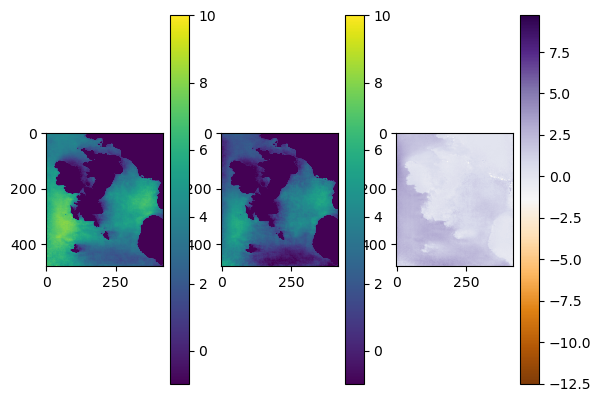

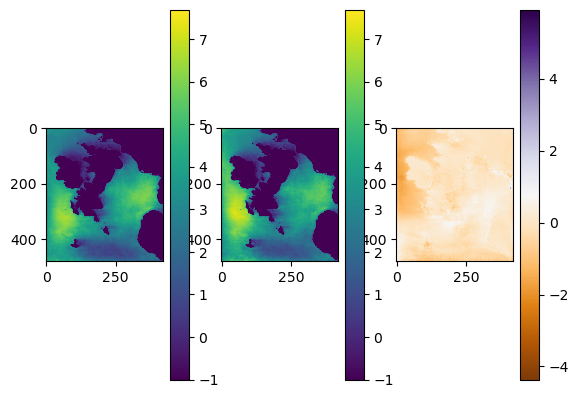

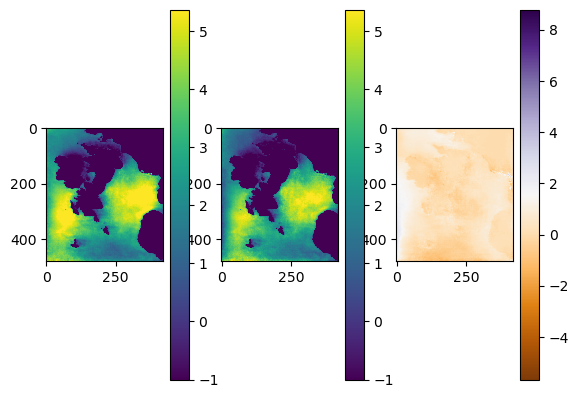

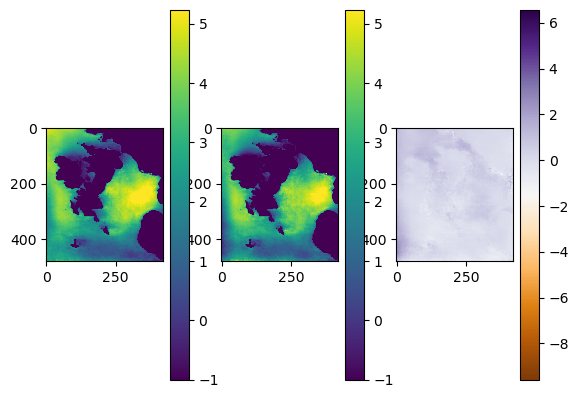

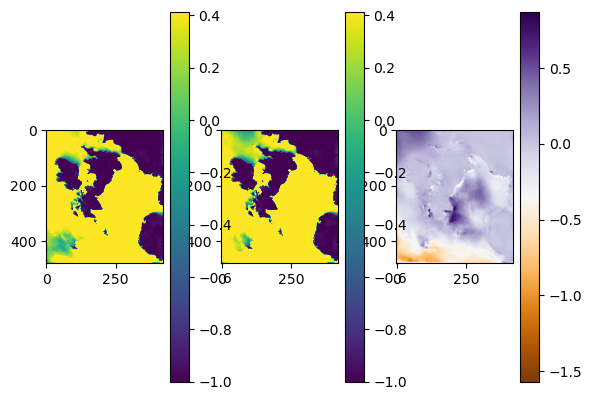

...

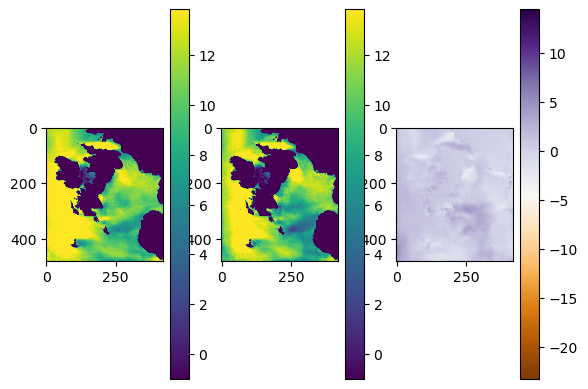

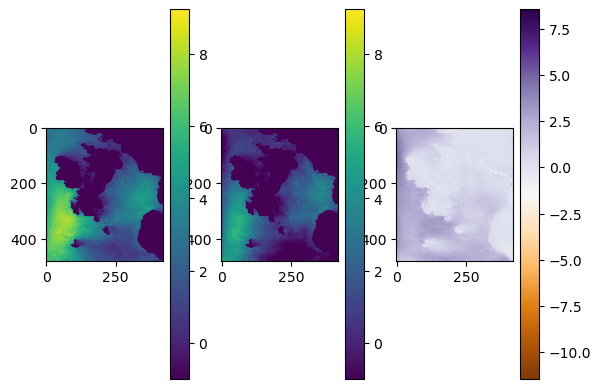

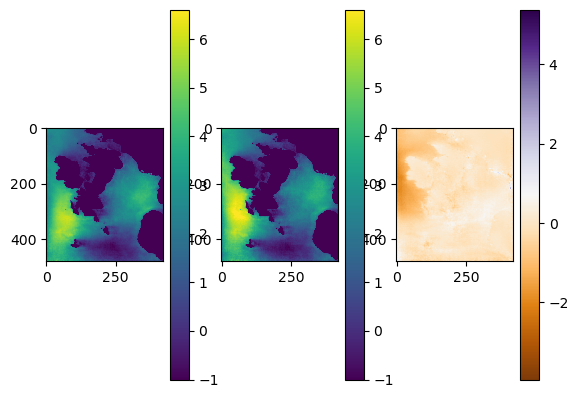

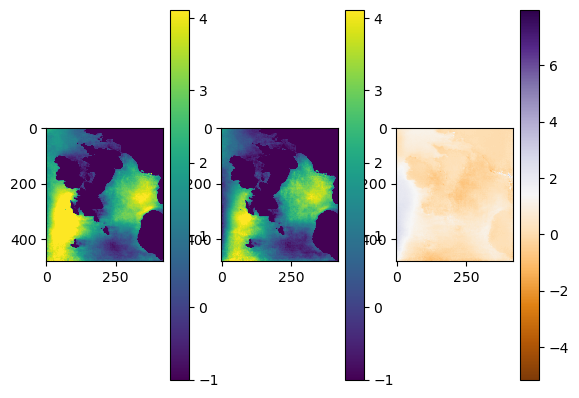

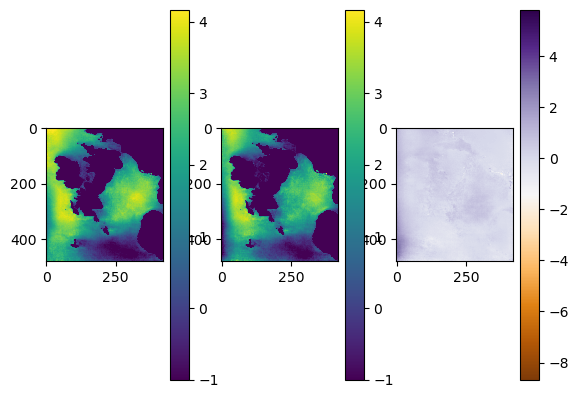

In [8]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    bnd_perturbed = bnd + tf.random.normal(bnd.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd, ywnd, ssh, xcur, ycur, bnd_perturbed))
    for j, var in enumerate(output_variables):
        o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
        o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
        for k in range(min(batch_size, 8)):
            fig, axes = plt.subplots(ncols=3)
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))
            im_pred = axes[0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            im_pred_perturbed = axes[1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            im_diff = axes[2].imshow(diff, cmap='PuOr')
            # im_truth = axes[1].imshow(o[j][k, ..., 0], vmin=vmin, vmax=vmax)
            plt.colorbar(im_pred)
            plt.colorbar(im_pred_perturbed)
            plt.colorbar(im_diff)

2024-07-16 09:11:56.804166: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2024-07-16 09:11:56.804275: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


1/1 [==============================] - 0s 42ms/step


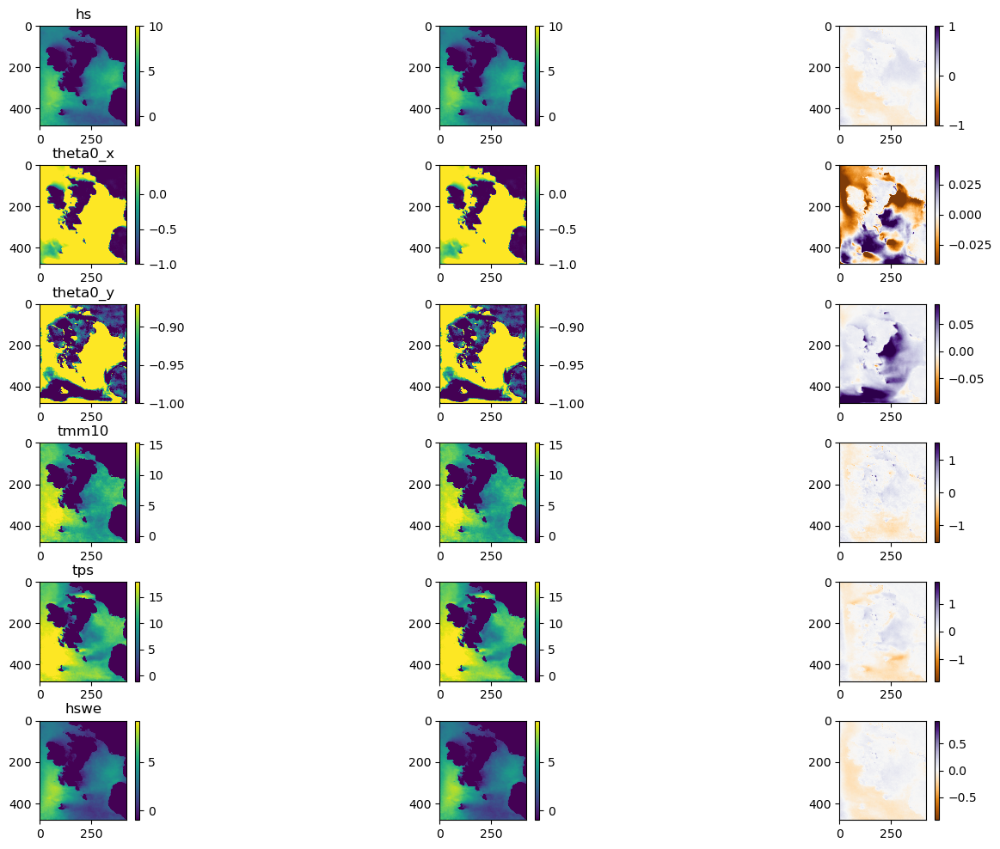

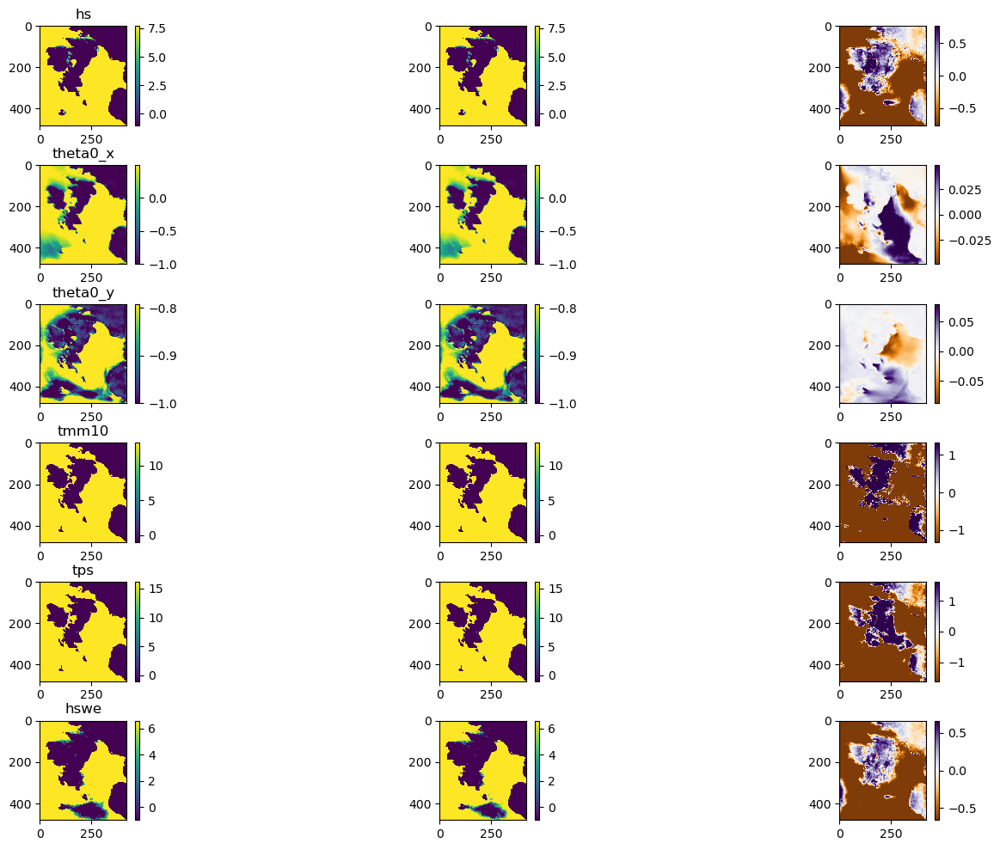

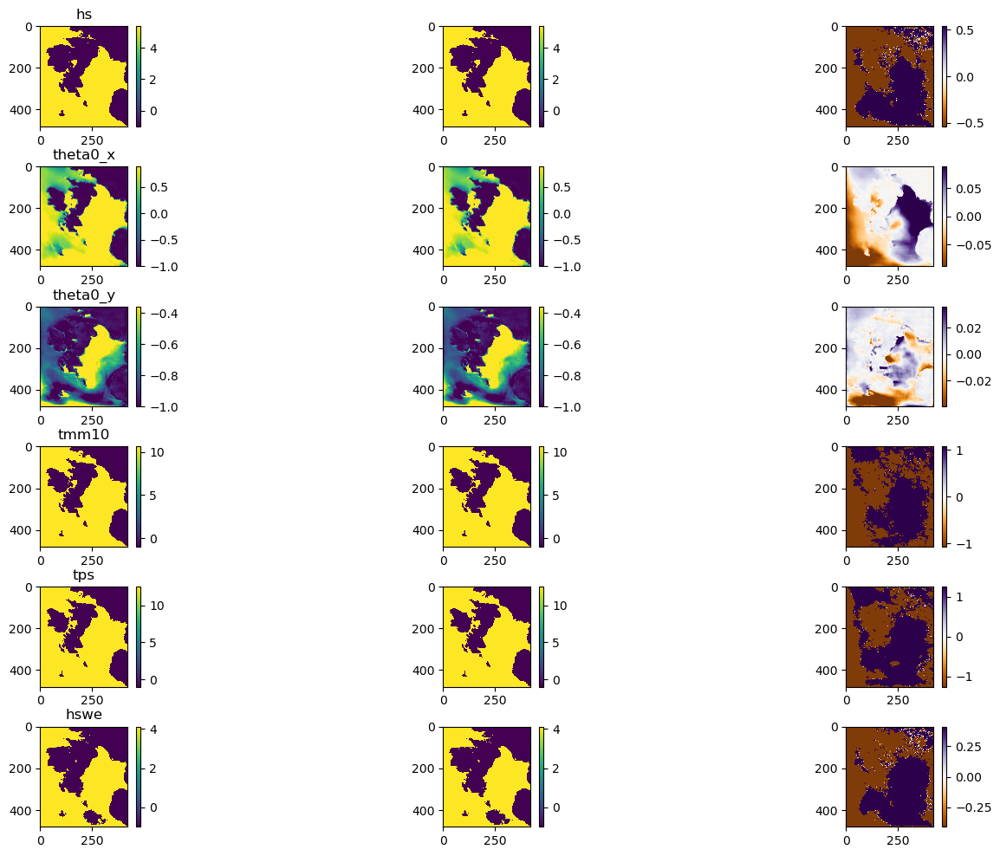

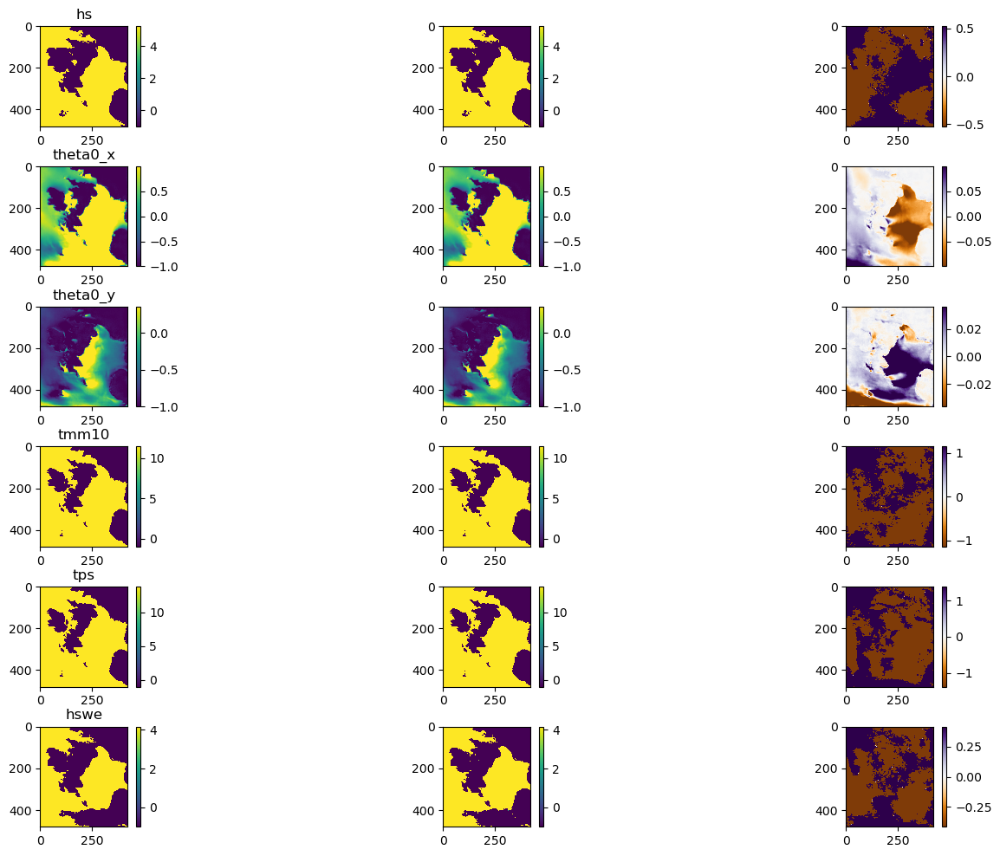

In [8]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    xwnd_perturbed = xwnd + tf.random.normal(xwnd.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd_perturbed, ywnd, ssh, xcur, ycur, bnd))
    for k in range(min(batch_size, 8)):
        fig, axes = plt.subplots(nrows=len(output_variables), ncols=3, figsize=(16, 12))
        plt.subplots_adjust(wspace=0.5, hspace=0.4)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))

            axes[j, 0].set_title(var)
            im_pred = axes[j, 0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 0])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)

            im_pred_perturbed = axes[j, 1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred_perturbed, cax=cax)
            
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            vmin_dif = -0.1 * vmax
            vmax_dif = 0.1 * vmax
            im_diff = axes[j, 2].imshow(diff, cmap='PuOr', vmin=vmin_dif, vmax=vmax_dif)
            divider = make_axes_locatable(axes[j, 2])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_diff, cax=cax)
            

1/1 [==============================] - 2s 2s/step


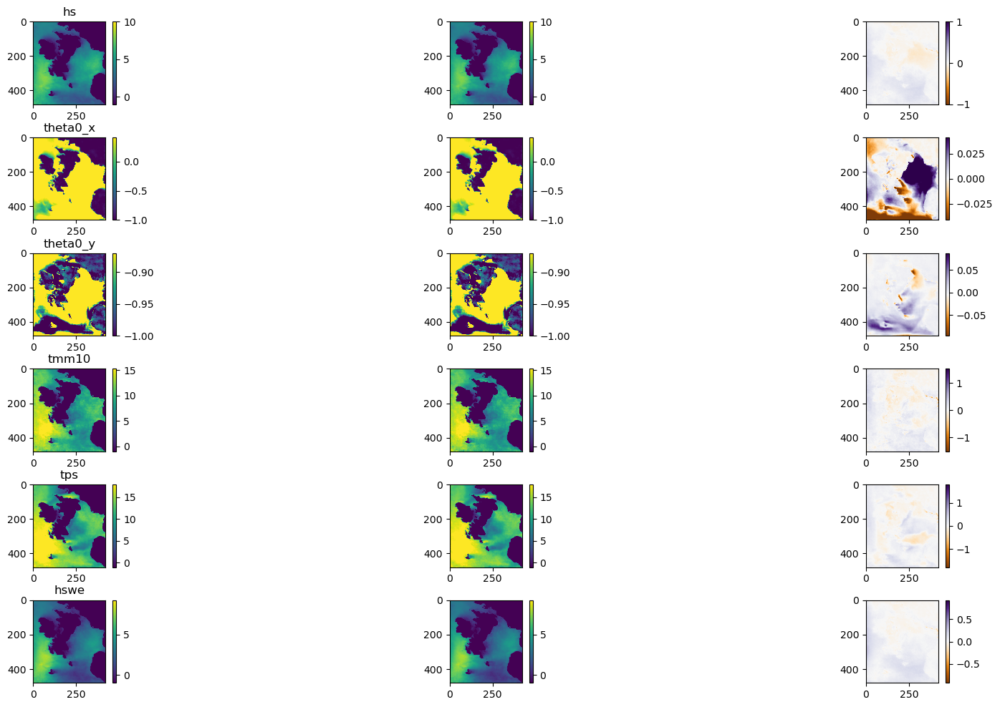

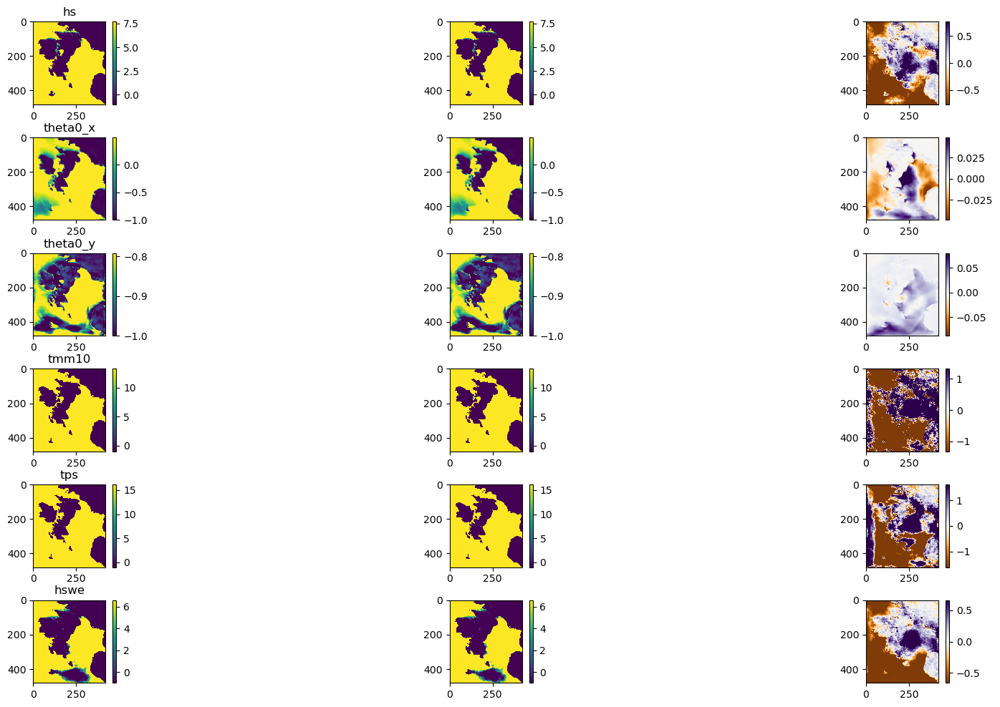

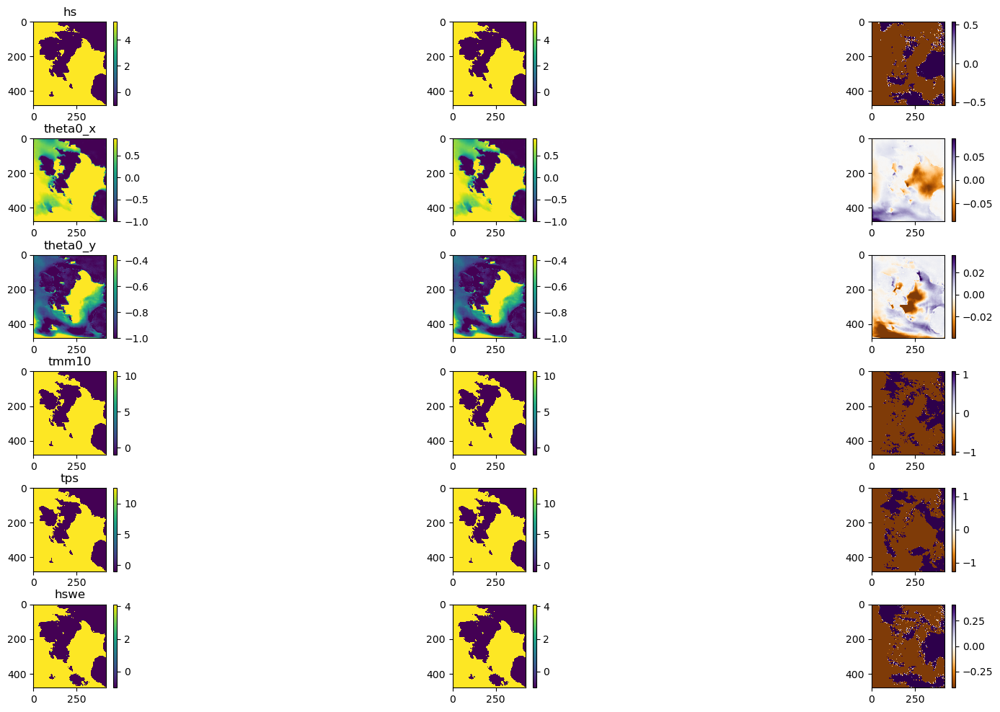

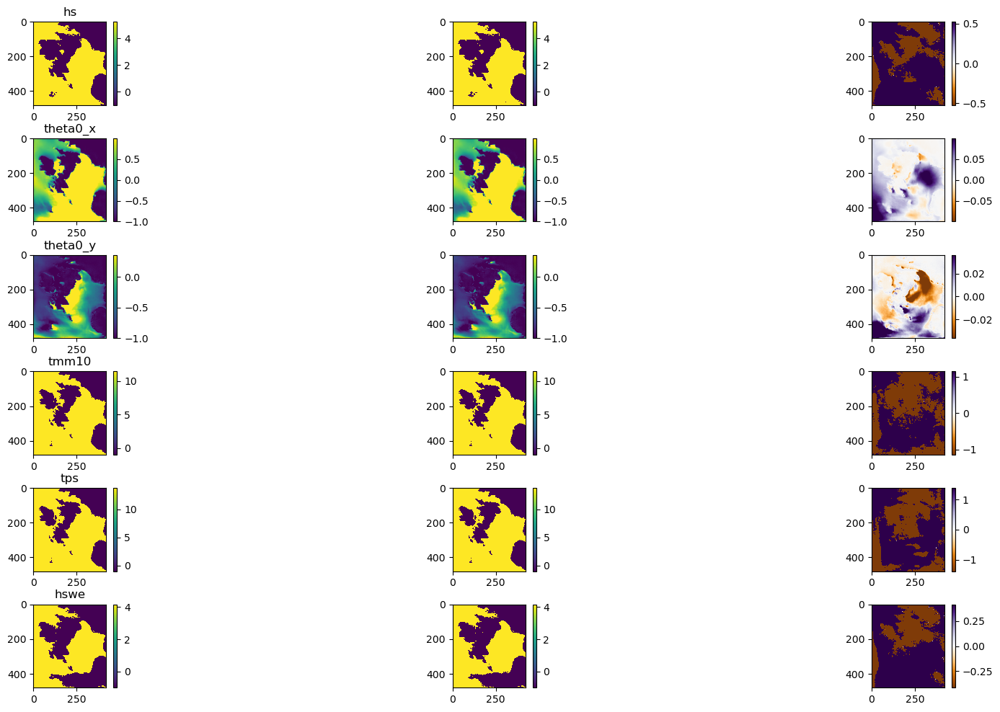

In [9]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    ywnd_perturbed = ywnd + tf.random.normal(ywnd.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd, ywnd_perturbed, ssh, xcur, ycur, bnd))
    for k in range(min(batch_size, 8)):
        fig, axes = plt.subplots(nrows=len(output_variables), ncols=3, figsize=(20, 12))
        plt.subplots_adjust(wspace=0.5, hspace=0.4)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))

            axes[j, 0].set_title(var)
            im_pred = axes[j, 0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 0])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)

            im_pred_perturbed = axes[j, 1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred_perturbed, cax=cax)
            
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            vmin_dif = -0.1 * vmax
            vmax_dif = 0.1 * vmax
            im_diff = axes[j, 2].imshow(diff, cmap='PuOr', vmin=vmin_dif, vmax=vmax_dif)
            divider = make_axes_locatable(axes[j, 2])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_diff, cax=cax)
            

2024-07-16 09:14:27.391748: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:392] Filling up shuffle buffer (this may take a while): 753 of 1000
2024-07-16 09:14:29.692839: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:417] Shuffle buffer filled.


1/1 [==============================] - 0s 46ms/step


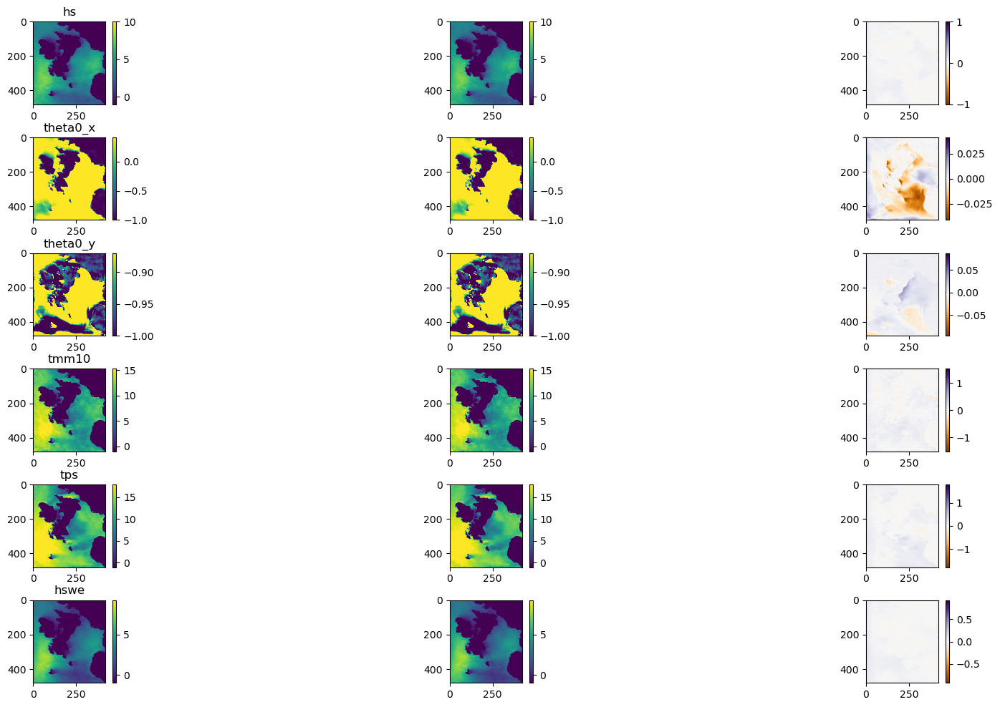

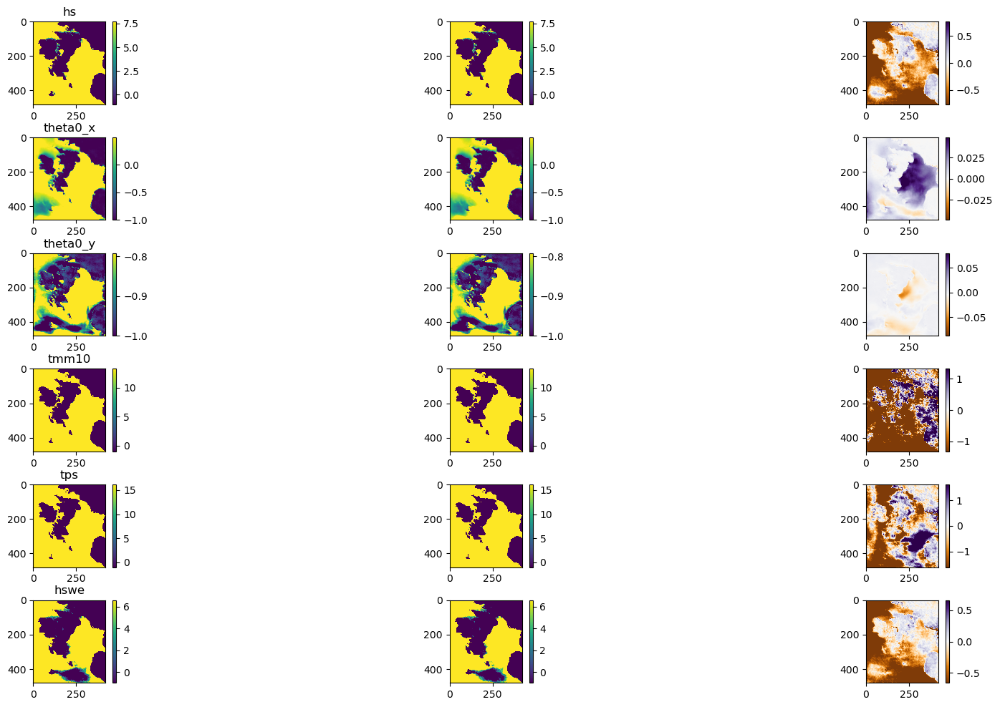

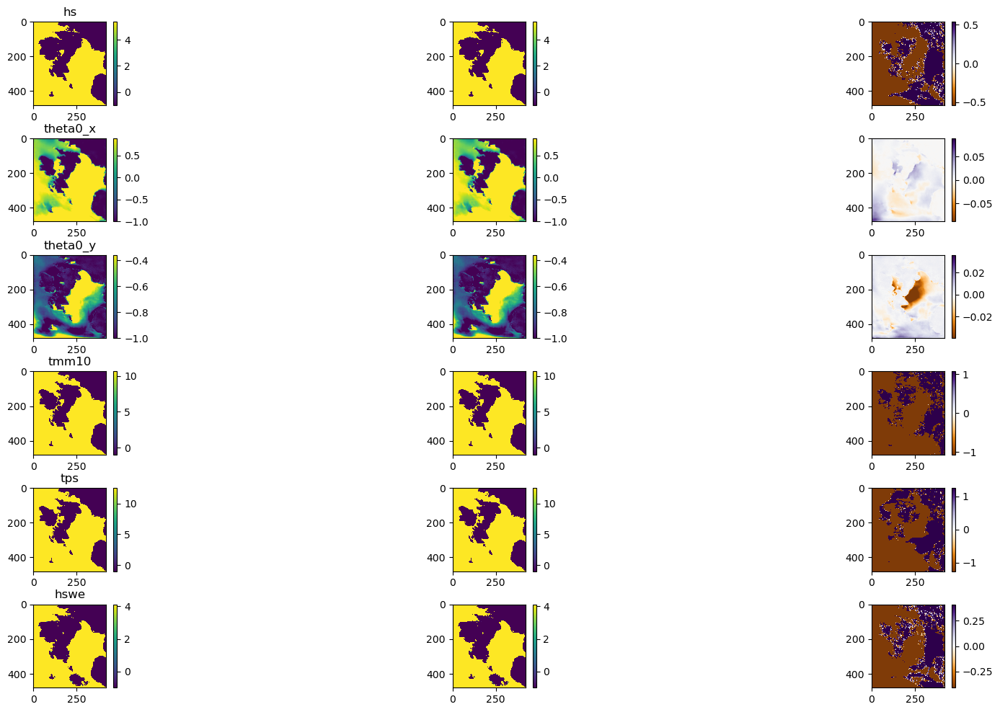

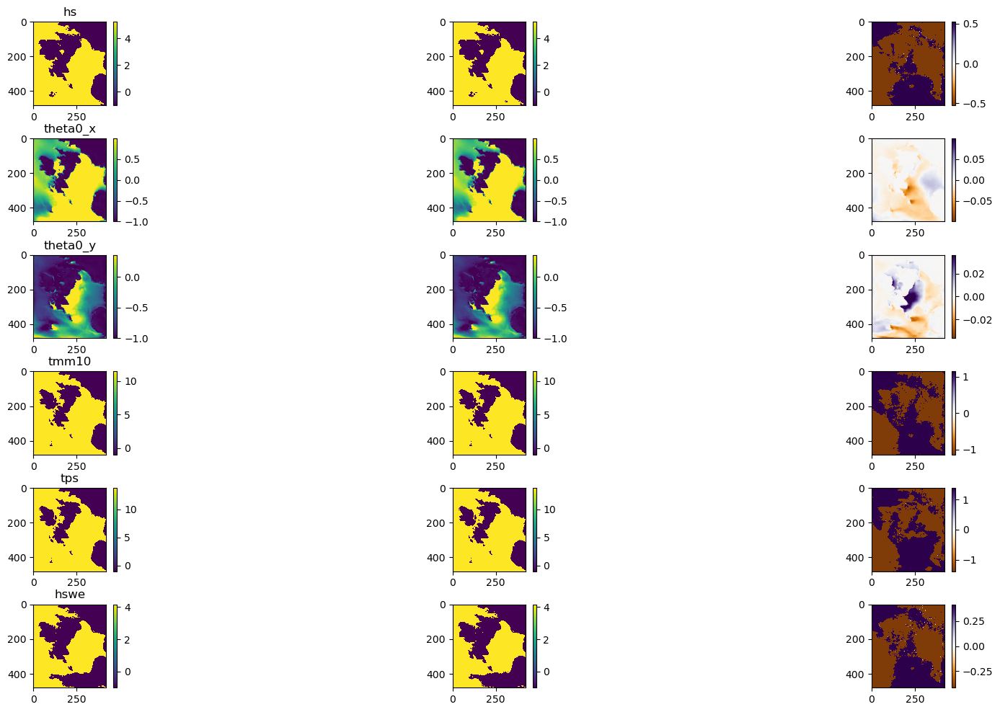

In [10]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    ssh_perturbed = ssh + tf.random.normal(ssh.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd, ywnd, ssh_perturbed, xcur, ycur, bnd))
    for k in range(min(batch_size, 8)):
        fig, axes = plt.subplots(nrows=len(output_variables), ncols=3, figsize=(20, 12))
        plt.subplots_adjust(wspace=0.5, hspace=0.4)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))

            axes[j, 0].set_title(var)
            im_pred = axes[j, 0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 0])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)

            im_pred_perturbed = axes[j, 1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred_perturbed, cax=cax)
            
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            vmin_dif = -0.1 * vmax
            vmax_dif = 0.1 * vmax
            im_diff = axes[j, 2].imshow(diff, cmap='PuOr', vmin=vmin_dif, vmax=vmax_dif)
            divider = make_axes_locatable(axes[j, 2])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_diff, cax=cax)
            

1/1 [==============================] - 0s 42ms/step


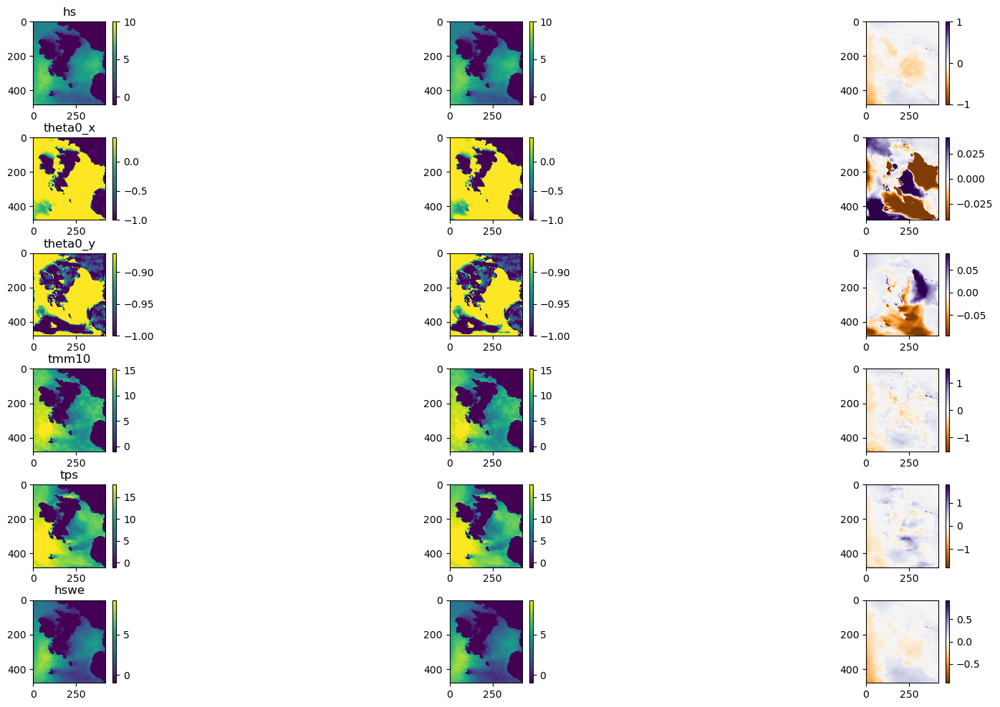

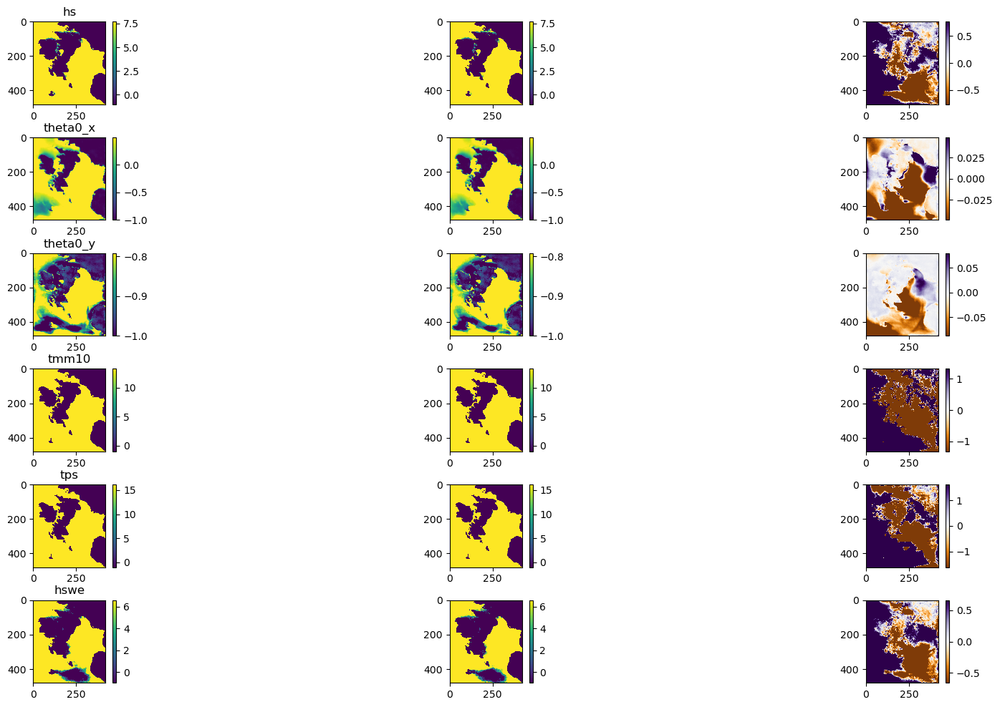

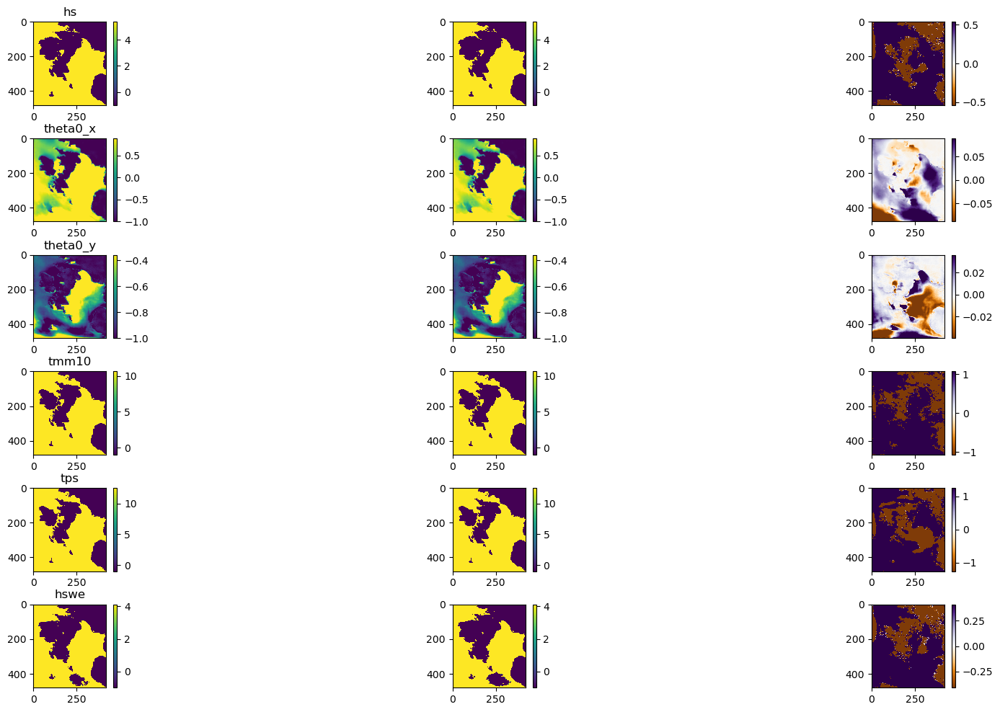

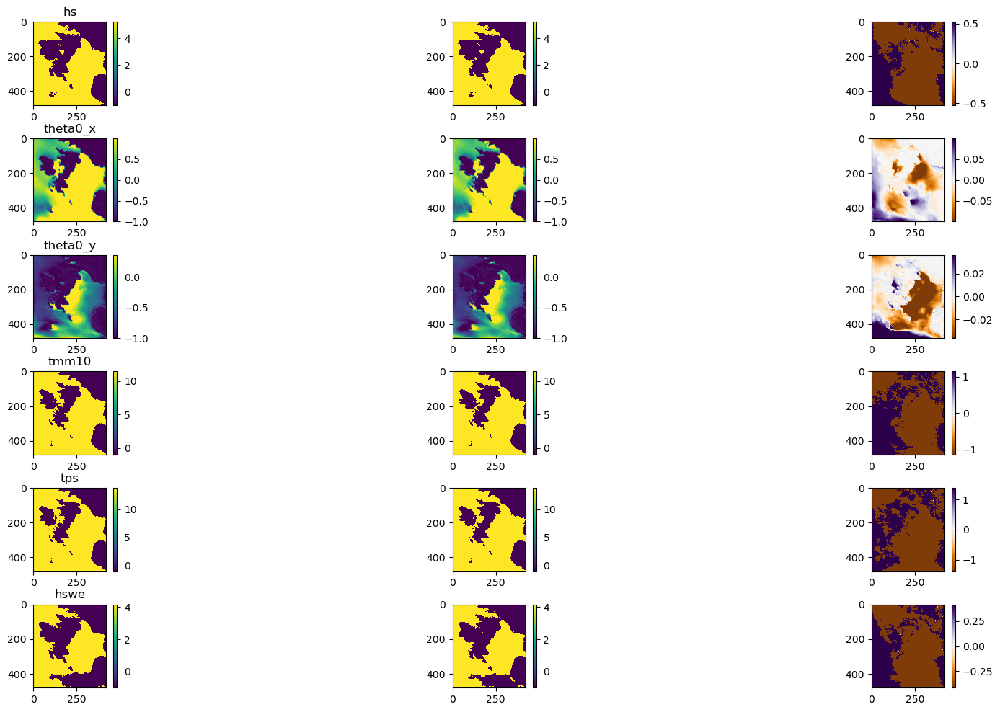

In [11]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    xcur_perturbed = xcur + tf.random.normal(xcur.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd, ywnd, ssh, xcur_perturbed, ycur, bnd))
    for k in range(min(batch_size, 8)):
        fig, axes = plt.subplots(nrows=len(output_variables), ncols=3, figsize=(20, 12))
        plt.subplots_adjust(wspace=0.5, hspace=0.4)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))

            axes[j, 0].set_title(var)
            im_pred = axes[j, 0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 0])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)

            im_pred_perturbed = axes[j, 1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred_perturbed, cax=cax)
            
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            vmin_dif = -0.1 * vmax
            vmax_dif = 0.1 * vmax
            im_diff = axes[j, 2].imshow(diff, cmap='PuOr', vmin=vmin_dif, vmax=vmax_dif)
            divider = make_axes_locatable(axes[j, 2])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_diff, cax=cax)
            

1/1 [==============================] - 0s 43ms/step


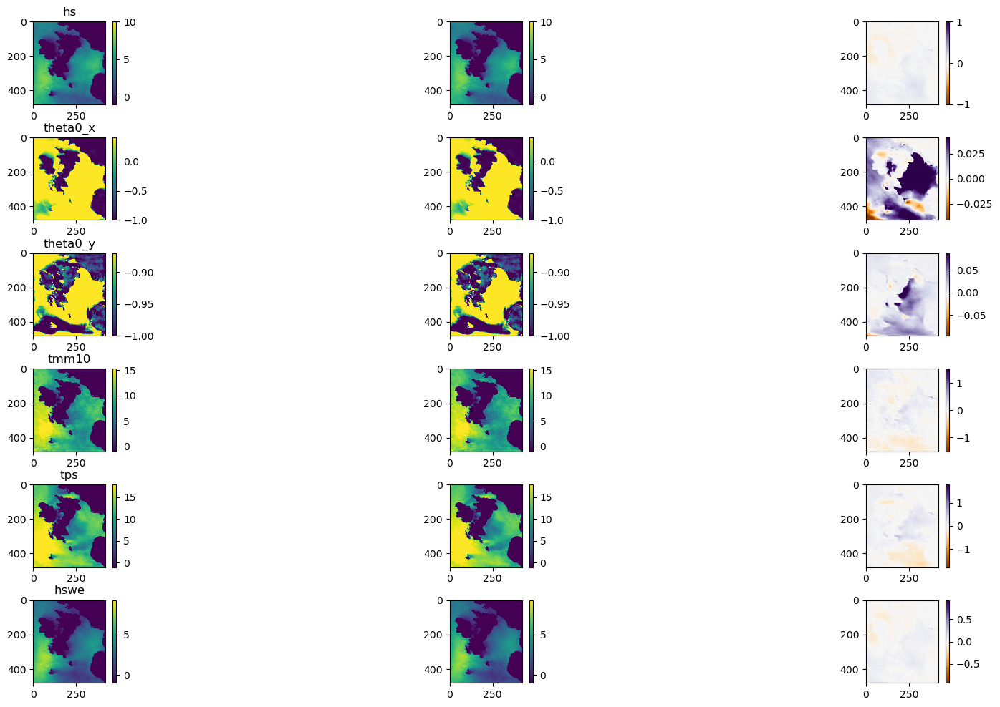

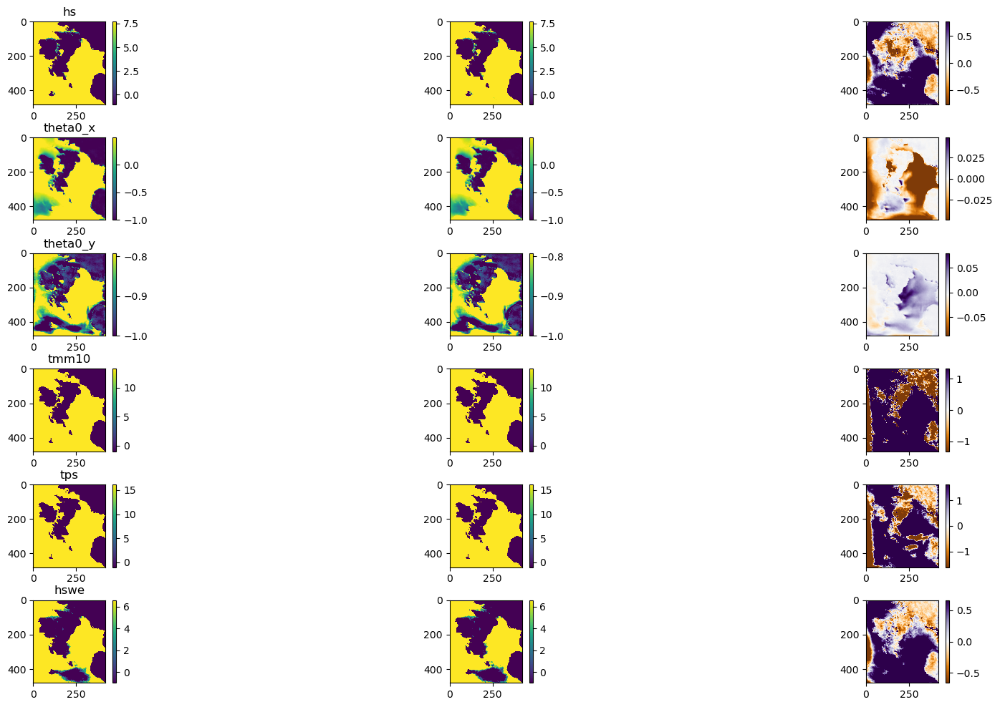

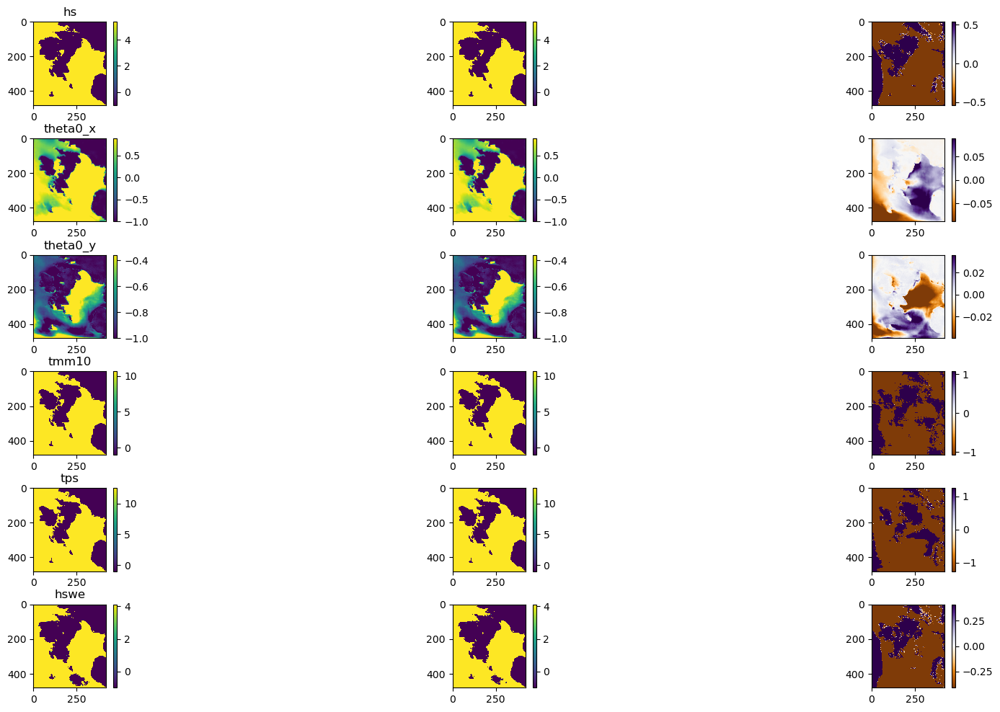

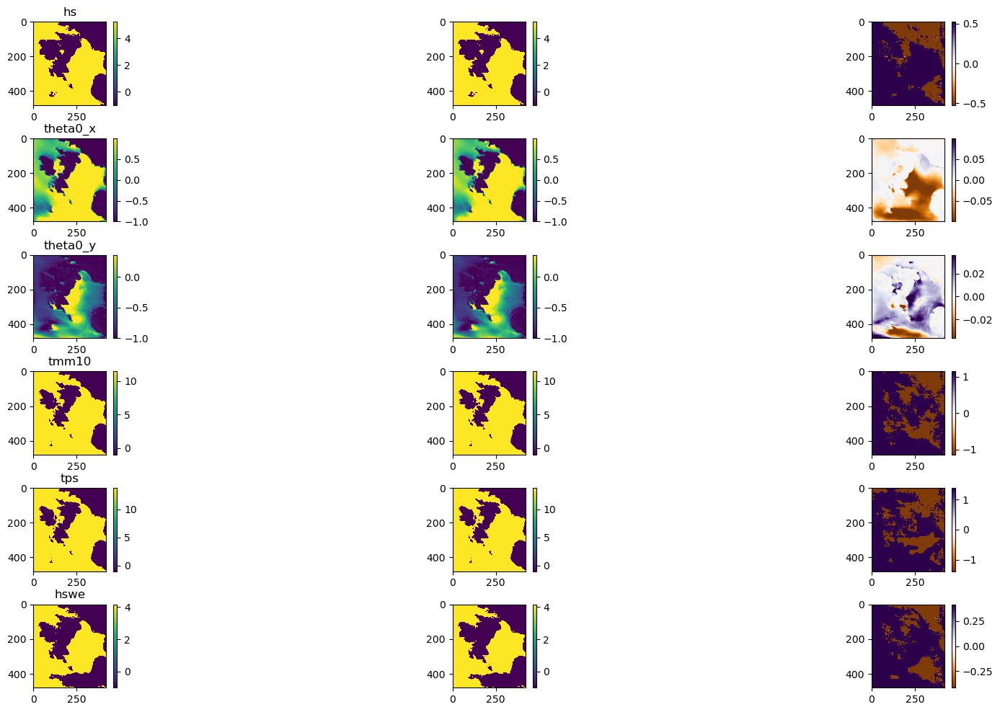

In [12]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    ycur_perturbed = ycur + tf.random.normal(ycur.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd, ywnd, ssh, xcur, ycur_perturbed, bnd))
    for k in range(min(batch_size, 8)):
        fig, axes = plt.subplots(nrows=len(output_variables), ncols=3, figsize=(20, 12))
        plt.subplots_adjust(wspace=0.5, hspace=0.4)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))

            axes[j, 0].set_title(var)
            im_pred = axes[j, 0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 0])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)

            im_pred_perturbed = axes[j, 1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred_perturbed, cax=cax)
            
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            vmin_dif = -0.1 * vmax
            vmax_dif = 0.1 * vmax
            im_diff = axes[j, 2].imshow(diff, cmap='PuOr', vmin=vmin_dif, vmax=vmax_dif)
            divider = make_axes_locatable(axes[j, 2])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_diff, cax=cax)
            

1/1 [==============================] - 0s 42ms/step


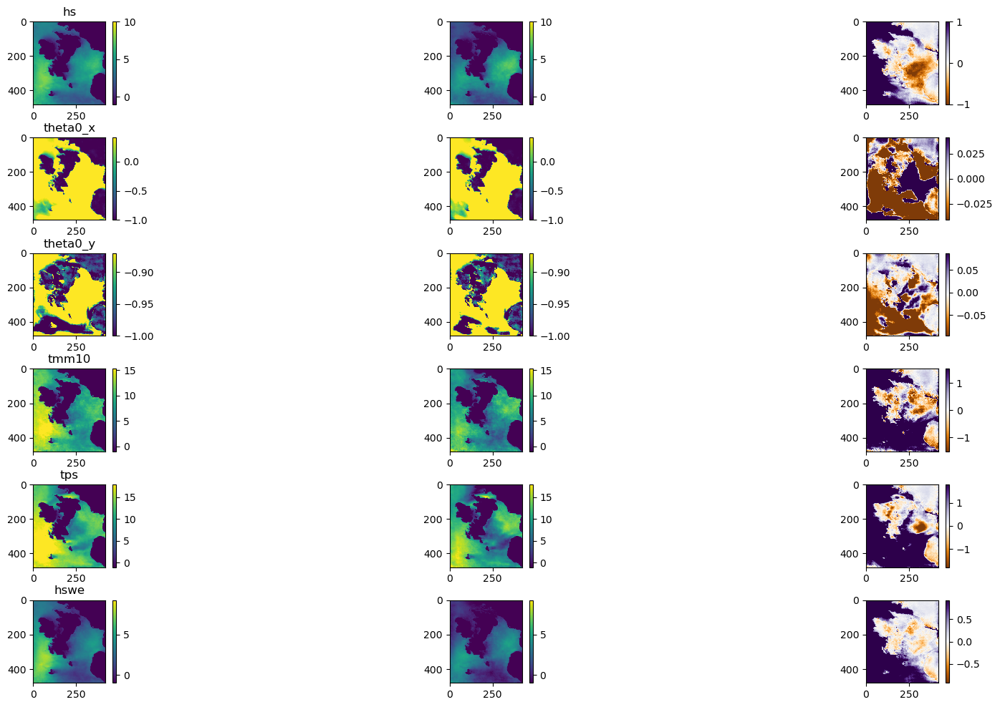

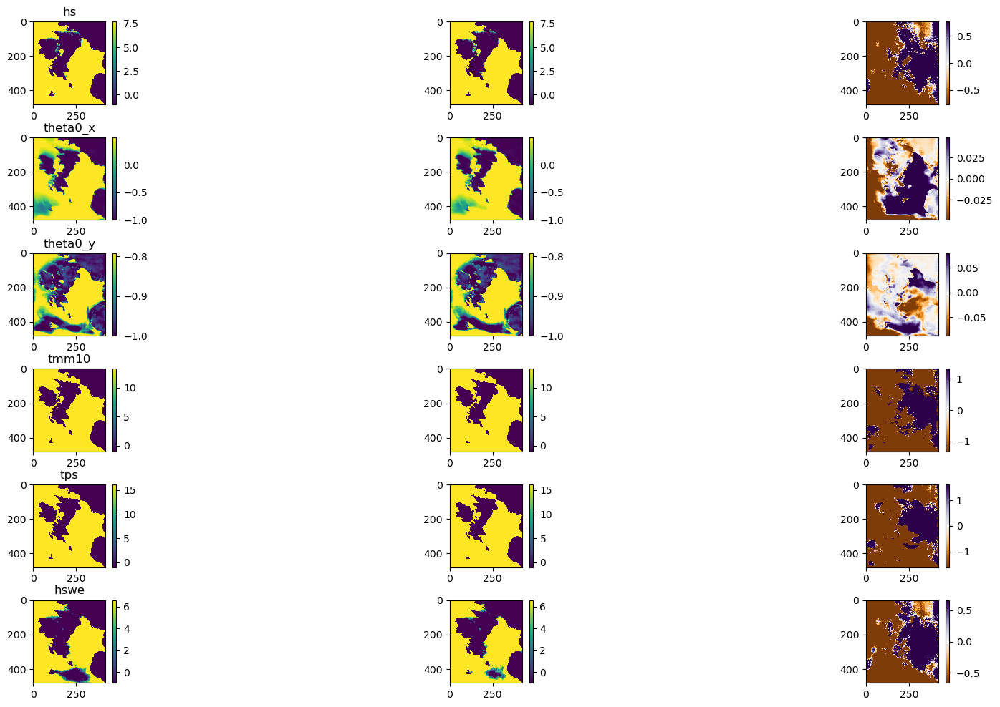

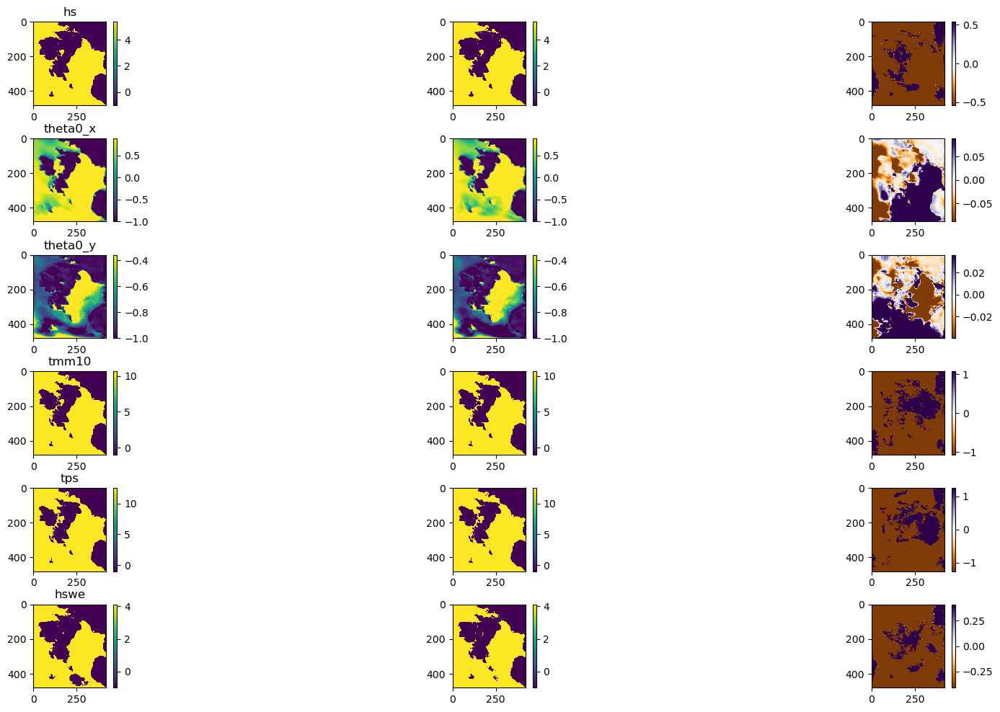

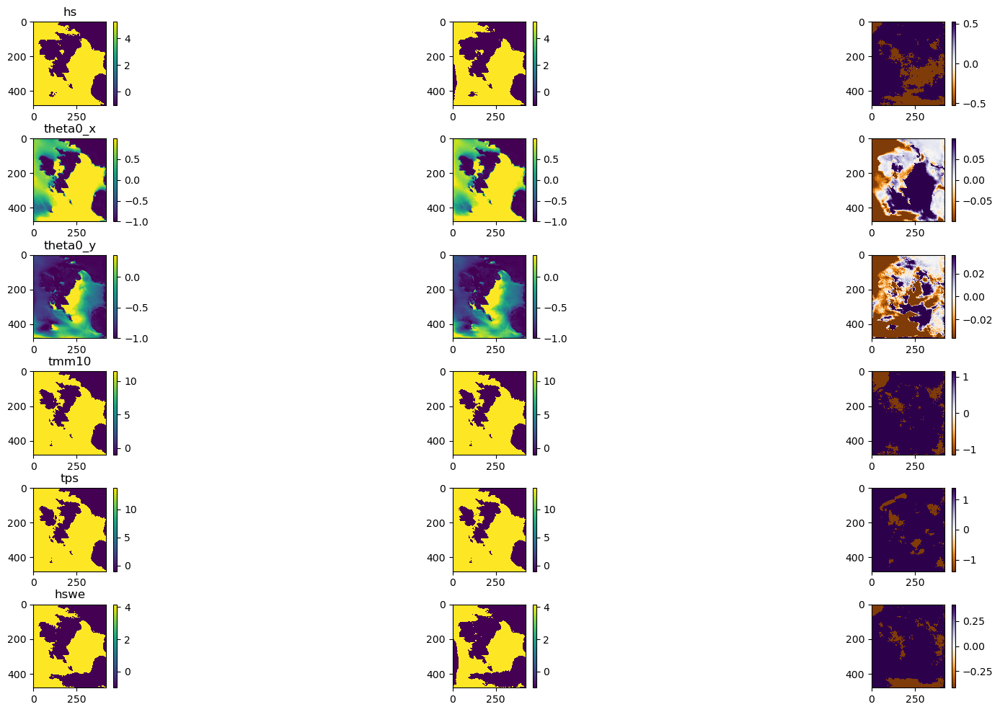

In [13]:
for i, o in test_dataset.take(1):
    xwnd, ywnd, ssh, xcur, ycur, bnd = i
    bnd_perturbed = bnd + tf.random.normal(bnd.shape, 0, 0.1)
    o_pred = model.predict(i)
    o_pred_perturbed = model.predict((xwnd, ywnd, ssh, xcur, ycur, bnd_perturbed))
    for k in range(min(batch_size, 8)):
        fig, axes = plt.subplots(nrows=len(output_variables), ncols=3, figsize=(20, 12))
        plt.subplots_adjust(wspace=0.5, hspace=0.4)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            vmin, vmax = np.percentile(o[j][k, ... ,0], (5, 95))

            axes[j, 0].set_title(var)
            im_pred = axes[j, 0].imshow(o_pred[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 0])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred, cax=cax)

            im_pred_perturbed = axes[j, 1].imshow(o_pred_perturbed[j][k, ..., 0], vmin=vmin, vmax=vmax)
            divider = make_axes_locatable(axes[j, 1])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_pred_perturbed, cax=cax)
            
            diff = o_pred[j][k, ..., 0] - o_pred_perturbed[j][k, ..., 0]
            vmin_dif = -0.1 * vmax
            vmax_dif = 0.1 * vmax
            im_diff = axes[j, 2].imshow(diff, cmap='PuOr', vmin=vmin_dif, vmax=vmax_dif)
            divider = make_axes_locatable(axes[j, 2])
            cax = divider.append_axes("right", size="5%", pad=0.10)
            cb = plt.colorbar(im_diff, cax=cax)
            

In [7]:
input_numbers = {0: "xwnd", 1: "ywnd", 2: "ssh", 3: "xcur", 4: "ycur", 5: "bnd"}

In [7]:
for i, o in test_dataset.take(10):
    print(i[0].shape, o[0].shape)

(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)
(4, 481, 421, 2) (4, 481, 421, 1)


In [8]:
def mae(a, b, axis=None):
    abs_diff = np.abs(a - b)
    return np.mean(abs_diff, axis=axis)

In [9]:
n = len(list(test_dataset))

In [25]:
dfs = {}
for input_number, var in input_numbers.items():
    dfs[var] = {}
    for o_var in output_variables:
        dfs[var][o_var] = []

In [26]:
for i, o in test_dataset.take(n):
    for input_number in input_numbers.keys():
        perturbed = i[input_number] + tf.random.normal(i[input_number].shape, 0, 0.1)
        i_perturbed = list(i)
        i_perturbed[input_number] = perturbed
        i_perturbed = tuple(i_perturbed)
        o_pred = model.predict(i)
        o_pred_perturbed = model.predict(i_perturbed)
        for j, var in enumerate(output_variables):
            o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
            o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
            
            diff = o_pred[j] - o_pred_perturbed[j]
            dfs[input_numbers[input_number]][var].append(mae(o_pred[j], o_pred_perturbed[j], axis=(1, 2, 3)))

1/1 [==============================] - 0s 43ms/step


In [27]:
for var in dfs.keys():
    for var_o in dfs[var].keys():
        dfs[var][var_o] = np.array(dfs[var][var_o]).flatten()

In [28]:
dfxwnd = pd.DataFrame(dfs['xwnd'])
dfywnd = pd.DataFrame(dfs['ywnd'])
dfbnd = pd.DataFrame(dfs['bnd'])
dfssh = pd.DataFrame(dfs['ssh'])

In [29]:
print(dfxwnd['hs'].mean())
print(dfywnd['hs'].mean())
print(dfbnd['hs'].mean())

0.08473347872495651
0.0720657929778099
0.6862871050834656


In [32]:
dfssh

,hs,theta0_x,theta0_y,tmm10,tps,hswe
0,0.021527,0.009801,0.006574,0.052670,0.064889,0.019865
1,0.059755,0.014914,0.005505,0.101606,0.130771,0.063928
2,0.035226,0.008776,0.007726,0.068954,0.070781,0.033666
3,0.053677,0.009913,0.005812,0.104546,0.114610,0.062008
4,0.035698,0.010510,0.005515,0.060049,0.060515,0.034675
...,...,...,...,...,...,...
895,0.094511,0.018062,0.008437,0.134131,0.151899,0.100559
896,0.036957,0.008377,0.005232,0.055712,0.065776,0.036652
897,0.030166,0.007344,0.003996,0.051052,0.060081,0.029416
898,0.036718,0.019399,0.005805,0.056900,0.069122,0.034226


In [ ]:
datasets = {}
for _ in range(10):
    dfs = {}
    for input_number, var in input_numbers.items():
        dfs[var] = {}
        for o_var in output_variables:
            dfs[var][o_var] = []
    
    for i, o in test_dataset.take(n):
        for input_number in input_numbers.keys():
            perturbed = i[input_number] + tf.random.normal(i[input_number].shape, 0, 0.1)
            i_perturbed = list(i)
            i_perturbed[input_number] = perturbed
            i_perturbed = tuple(i_perturbed)
            o_pred = model.predict(i)
            o_pred_perturbed = model.predict(i_perturbed)
            for j, var in enumerate(output_variables):
                o_pred[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[j] + min_max_values[var].values[0]
                o_pred_perturbed[j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred_perturbed[j] + min_max_values[var].values[0]
                
                diff = o_pred[j] - o_pred_perturbed[j]
                dfs[input_numbers[input_number]][var].append(mae(o_pred[j], o_pred_perturbed[j], axis=(1, 2, 3)))
    
    for var in dfs.keys():
        for var_o in dfs[var].keys():
            dfs[var][var_o] = np.array(dfs[var][var_o]).flatten()
        df = pd.DataFrame(dfs[var])
        ds = df.to_xarray().rename({'index': 'sample'})
        if _ == 0:
            datasets[var] = ds
        else:
            datasets[var] = xr.concat([datasets[var], ds], dim='iteration')
        

1/1 [==============================] - ETA: 0s

In [60]:
for var in datasets.keys():
    datasets[var] = datasets[var].assign_coords(iteration=datasets[var].iteration)
datasets['xwnd']

<xarray.Dataset>
Dimensions:    (sample: 900, iteration: 10)
Coordinates:
  * sample     (sample) int64 0 1 2 3 4 5 6 7 ... 893 894 895 896 897 898 899
  * iteration  (iteration) int64 0 1 2 3 4 5 6 7 8 9
Data variables:
    hs         (iteration, sample) float32 0.1164 0.1612 ... 0.0533 0.107
    theta0_x   (iteration, sample) float32 0.02845 0.03345 ... 0.01533 0.02867
    theta0_y   (iteration, sample) float32 0.01229 0.009086 ... 0.009289 0.01023
    tmm10      (iteration, sample) float32 0.1628 0.24 0.1124 ... 0.1102 0.1319
    tps        (iteration, sample) float32 0.1751 0.2514 ... 0.1203 0.1607
    hswe       (iteration, sample) float32 0.1007 0.1624 ... 0.04971 0.07908

In [62]:
for var in datasets.keys():
    datasets[var].to_netcdf(analysis_dir / f'{var}.nc')

In [71]:
datasets['bnd'].hs.mean()

<xarray.DataArray 'hs' ()>
array(0.68055356, dtype=float32)

In [70]:
datasets['xwnd'].hs.mean()

<xarray.DataArray 'hs' ()>
array(0.08602654, dtype=float32)

In [68]:
datasets['ywnd'].hs.mean()

<xarray.DataArray 'hs' ()>
array(0.07238711, dtype=float32)